In [ ]:
Here summarization what we do is?

- We send n last messages + summarization of previous messages before n through different LLM 
  and delete all those messages 
- Finally we send Summarization of previous messages from n + n last messsages to llm so that they 
  have context of whole conversation from start to recent so that LLM dont Hallucinate or give random answers

In [3]:
from langgraph.graph import MessagesState
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START,END
from langgraph.checkpoint.memory import InMemorySaver
import os

In [4]:
load_dotenv()
api_key = os.getenv("OPENROUTER_API_KEY")

In [ ]:
llm = ChatOpenAI(
    model="meta-llama/llama-3.3-70b-instruct:free",
    api_key=api_key,
    base_url="https://openrouter.ai/api/v1",
    temperature=0
)

In [6]:
class ChatState(MessagesState):
    summary: str

In [7]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above and should cover all important topics of conversation."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = llm.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [8]:
def chat_node(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])

    print(messages)

    response = llm.invoke(messages)
    return {"messages": [response]}

In [9]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

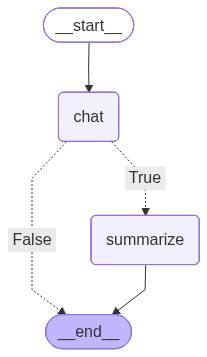

In [11]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: END,
    }
)

builder.add_edge("summarize", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

graph

In [12]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [ ]:
# gives the current condition of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [14]:
run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='3b259d06-75f1-45b7-a2c4-8a22bc260067')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : Quantum physics (or quantum mechanics) is the fundamental theory describing the 


In [15]:
run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='3b259d06-75f1-45b7-a2c4-8a22bc260067'), AIMessage(content='Quantum physics (or quantum mechanics) is the fundamental theory describing the behavior of matter and energy at the smallest scales – atoms, subatomic particles, photons, and beyond. It reveals a reality drastically different from our everyday experience and classical physics. Here\'s a breakdown of its core concepts and significance:\n\n### Core Principles & Strange Phenomena\n\n1.  **Quantization:** Energy, momentum, angular momentum, and other properties are not continuous but come in discrete, indivisible packets called **quanta**. (e.g., photons are quanta of light energy).\n2.  **Wave-Particle Duality:** Particles (like electrons) can exhibit wave-like properties (interference, diffraction), and waves (like light) can exhibit particle-like properties (collisions, discrete energy). An entity\'s behavior depends on how you observe it.\

In [ ]:
run_turn('What are contributions of Einstein in Quantum physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='3b259d06-75f1-45b7-a2c4-8a22bc260067'), AIMessage(content='Quantum physics (or quantum mechanics) is the fundamental theory describing the behavior of matter and energy at the smallest scales – atoms, subatomic particles, photons, and beyond. It reveals a reality drastically different from our everyday experience and classical physics. Here\'s a breakdown of its core concepts and significance:\n\n### Core Principles & Strange Phenomena\n\n1.  **Quantization:** Energy, momentum, angular momentum, and other properties are not continuous but come in discrete, indivisible packets called **quanta**. (e.g., photons are quanta of light energy).\n2.  **Wave-Particle Duality:** Particles (like electrons) can exhibit wave-like properties (interference, diffraction), and waves (like light) can exhibit particle-like properties (collisions, discrete energy). An entity\'s behavior depends on how you observe it.\

In [18]:
run_turn('Explain theory of relativity given by einstein')
show_state()

[HumanMessage(content='What are contributions of Einstein in Quantum physics', additional_kwargs={}, response_metadata={}, id='4b91fb03-fb75-4d88-85fd-b855142b3d51'), AIMessage(content='Albert Einstein\'s contributions to physics revolutionized our understanding of the universe. While he is most famous for his theories of relativity, his work in quantum mechanics was equally groundbreaking—though he later became its most prominent critic. Here\'s a breakdown of his most famous works and quantum-specific contributions:\n\n---\n\n### **I. Einstein\'s Most Famous Works (Beyond Quantum Physics)**\n1. **Special Relativity (1905)**  \n   - **Core Idea:** Space and time are interwoven into a single continuum (**spacetime**), and the laws of physics are the same for all non-accelerating observers.  \n   - **Key Consequences:**  \n     - **E = mc²:** Mass and energy are equivalent (foundation for nuclear energy).  \n     - Time dilation (moving clocks run slow).  \n     - Length contraction (ob

In [19]:
run_turn('Einstein other Theories in quantum physics')
show_state()

[HumanMessage(content='What are contributions of Einstein in Quantum physics', additional_kwargs={}, response_metadata={}, id='4b91fb03-fb75-4d88-85fd-b855142b3d51'), AIMessage(content='Albert Einstein\'s contributions to physics revolutionized our understanding of the universe. While he is most famous for his theories of relativity, his work in quantum mechanics was equally groundbreaking—though he later became its most prominent critic. Here\'s a breakdown of his most famous works and quantum-specific contributions:\n\n---\n\n### **I. Einstein\'s Most Famous Works (Beyond Quantum Physics)**\n1. **Special Relativity (1905)**  \n   - **Core Idea:** Space and time are interwoven into a single continuum (**spacetime**), and the laws of physics are the same for all non-accelerating observers.  \n   - **Key Consequences:**  \n     - **E = mc²:** Mass and energy are equivalent (foundation for nuclear energy).  \n     - Time dilation (moving clocks run slow).  \n     - Length contraction (ob

In [20]:
run_turn('What is quantum physics')
show_state()

[HumanMessage(content='What are contributions of Einstein in Quantum physics', additional_kwargs={}, response_metadata={}, id='4b91fb03-fb75-4d88-85fd-b855142b3d51'), AIMessage(content='Albert Einstein\'s contributions to physics revolutionized our understanding of the universe. While he is most famous for his theories of relativity, his work in quantum mechanics was equally groundbreaking—though he later became its most prominent critic. Here\'s a breakdown of his most famous works and quantum-specific contributions:\n\n---\n\n### **I. Einstein\'s Most Famous Works (Beyond Quantum Physics)**\n1. **Special Relativity (1905)**  \n   - **Core Idea:** Space and time are interwoven into a single continuum (**spacetime**), and the laws of physics are the same for all non-accelerating observers.  \n   - **Key Consequences:**  \n     - **E = mc²:** Mass and energy are equivalent (foundation for nuclear energy).  \n     - Time dilation (moving clocks run slow).  \n     - Length contraction (ob